In [1]:
'''Import all necessary libraries'''
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb
from xgboost import XGBRegressor


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

C:\Users\dhruv\AppData\Local\Temp\ipykernel_1040\2867026071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
2020-01-07,71.995369,72.600975,71.775804,72.345220,108872000
2020-01-08,73.153481,73.455080,71.698566,71.698566,132079200
...,...,...,...,...,...
2025-12-31,271.859985,273.679993,271.750000,273.059998,27293600
2026-01-02,271.010010,277.839996,269.000000,272.260010,37838100


In [4]:
df['Close'][ticker]

Date
2020-01-02     72.468262
2020-01-03     71.763725
2020-01-06     72.335556
2020-01-07     71.995369
2020-01-08     73.153481
                 ...    
2025-12-31    271.859985
2026-01-02    271.010010
2026-01-05    267.260010
2026-01-06    262.359985
2026-01-07    260.329987
Name: AAPL, Length: 1512, dtype: float64

In [5]:
'''Setting up our train-test split and scaling'''
train_len = 30
X = []
y = []

for i in range(len(df['Close'][ticker])-train_len):
    X.append(df['Close'][ticker][i:i+train_len])
    y.append(df["Close"][ticker][i+train_len])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()
    

C:\Users\dhruv\AppData\Local\Temp\ipykernel_1040\3589141919.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(df["Close"][ticker][i+train_len])


In [6]:
'''Model Setup'''
model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [7]:
'''Evaluation'''
model.fit(
    X_train_scaled,
    y_train_scaled,
    eval_set=[(X_test_scaled, y_test_scaled)],
    verbose=True
)

[0]	validation_0-rmse:2.18042
[1]	validation_0-rmse:2.09734
[2]	validation_0-rmse:2.01903
[3]	validation_0-rmse:1.94260
[4]	validation_0-rmse:1.87121
[5]	validation_0-rmse:1.80281
[6]	validation_0-rmse:1.73971
[7]	validation_0-rmse:1.68004
[8]	validation_0-rmse:1.62354
[9]	validation_0-rmse:1.57039
[10]	validation_0-rmse:1.52076
[11]	validation_0-rmse:1.47077
[12]	validation_0-rmse:1.42499
[13]	validation_0-rmse:1.37987
[14]	validation_0-rmse:1.33745
[15]	validation_0-rmse:1.29903
[16]	validation_0-rmse:1.26324
[17]	validation_0-rmse:1.22681
[18]	validation_0-rmse:1.19242
[19]	validation_0-rmse:1.16043
[20]	validation_0-rmse:1.12868
[21]	validation_0-rmse:1.10080
[22]	validation_0-rmse:1.07323
[23]	validation_0-rmse:1.04632
[24]	validation_0-rmse:1.02044
[25]	validation_0-rmse:0.99632
[26]	validation_0-rmse:0.97343
[27]	validation_0-rmse:0.95184
[28]	validation_0-rmse:0.93126
[29]	validation_0-rmse:0.91171
[30]	validation_0-rmse:0.89331
[31]	validation_0-rmse:0.87760
[32]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [8]:
y_pred_scaled = model.predict(X_test_scaled)

In [9]:
rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).ravel(), scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()))

In [10]:
r2 = r2_score(scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).ravel(), scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel())

In [11]:
print(f"RMSE: {rmse:.4f}")
print(f"R2 score: {r2:.4f}")

RMSE: 20.6076
R2 score: 0.3284


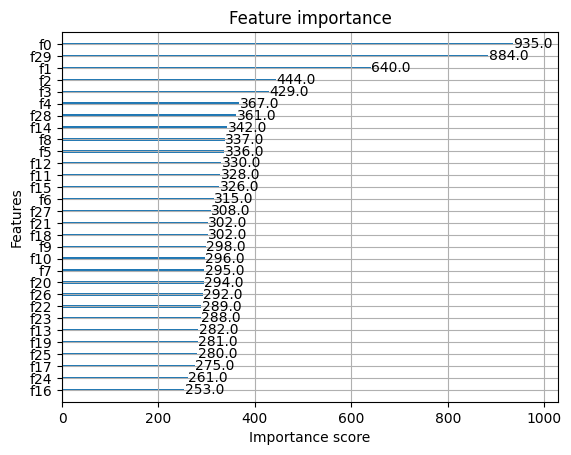

In [12]:
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()

As can be seen, our model appears to heavily rely upon the final day and the initial day in the window to predict the outcome.

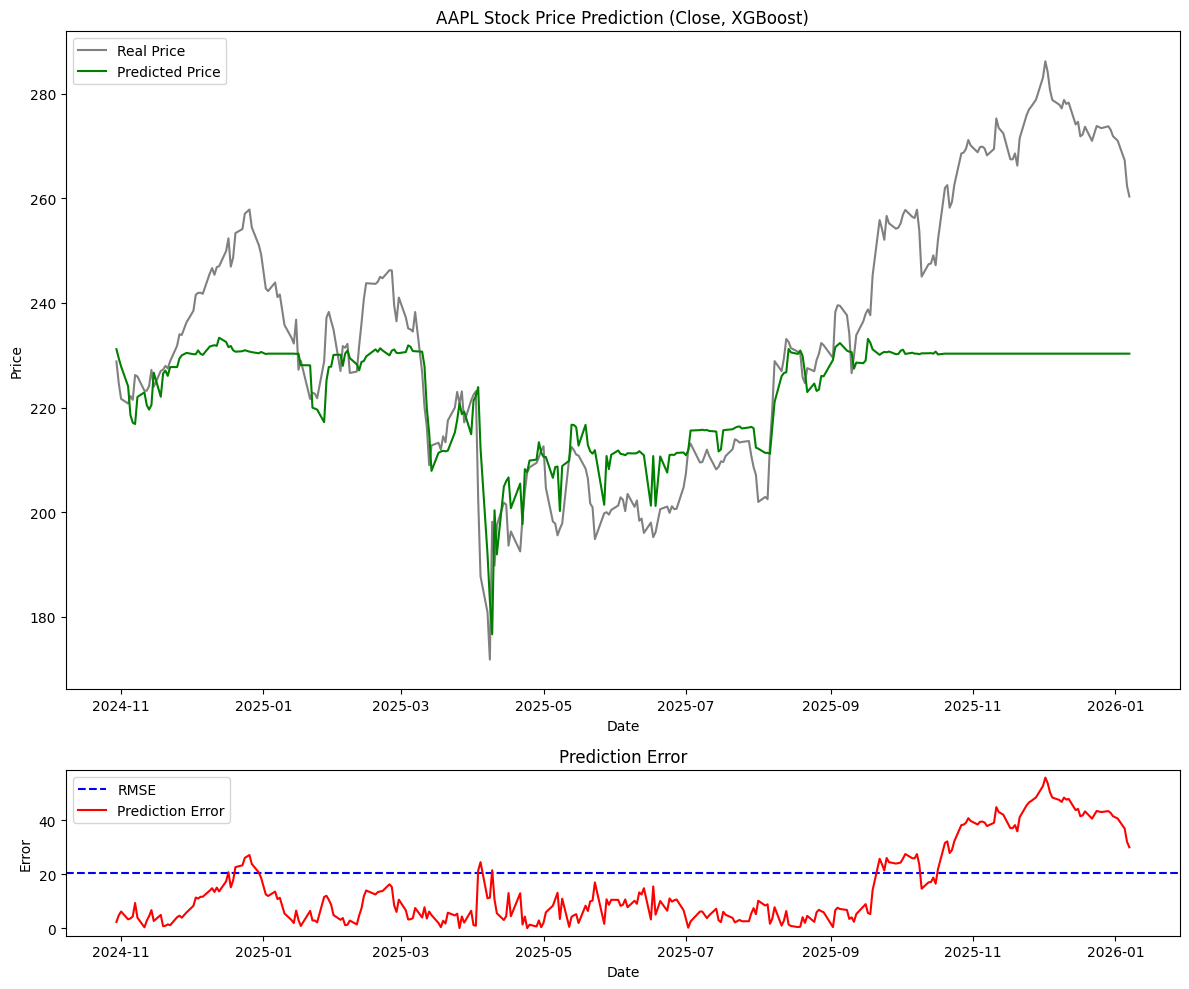

In [13]:
'''Plotting the results'''
y_pred_plot = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_test_plot = scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).ravel()

fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'gray', label = 'Real Price')
ax1.plot(df.iloc[-len(y_test):].index, y_pred_plot, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction (Close, XGBoost)")
plt.xlabel("Date")
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(rmse, color = 'blue', linestyle = '--', label = 'RMSE')
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test - y_pred_plot), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()

As can be seen, the main limitation with the XGBoost algorithm is that it is unable to extrapolate beyond its training data. Due to the upward trend of the stock market, we will undoubtedly see higher and higher peaks (in comparison to dips). Thus, when this occurs, the model has never seen such a thing in its training data, so it flatlines.